In [2]:
from pathlib import Path

import torch
from torch.utils.data import DataLoader, random_split
from torchvision import datasets
from torchvision import transforms

In [3]:
DATA_DIR = Path("/home/divye/Desktop/cnn/data/2750")

print(DATA_DIR.exists())

True


In [1]:
print("df")

df


In [19]:
train_transform = transforms.Compose([
    transforms.Resize((224,224)),

    transforms.RandomHorizontalFlip(),

    transforms.RandomRotation(15),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [20]:
test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [21]:
dataset = datasets.ImageFolder(
    root=DATA_DIR,
    transform=train_transform
)

print(len(dataset))

27000


In [22]:
classes = dataset.classes

print(classes)

print(len(classes))


['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
10


In [23]:
train_size = int(0.8 * len(dataset))

val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(
    dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)


In [24]:
full_dataset = datasets.ImageFolder(DATA_DIR)

train_indices = train_dataset.indices
val_indices = val_dataset.indices


In [25]:
train_dataset = torch.utils.data.Subset(
    datasets.ImageFolder(DATA_DIR, transform=train_transform),
    train_indices
)

val_dataset = torch.utils.data.Subset(
    datasets.ImageFolder(DATA_DIR, transform=test_transform),
    val_indices
)


In [26]:
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

In [27]:
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

/home/divye/Desktop/cnn/venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:1102: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


torch.Size([32, 3, 224, 224])
torch.Size([32])


In [28]:
print(dataset.class_to_idx)

{'AnnualCrop': 0, 'Forest': 1, 'HerbaceousVegetation': 2, 'Highway': 3, 'Industrial': 4, 'Pasture': 5, 'PermanentCrop': 6, 'Residential': 7, 'River': 8, 'SeaLake': 9}


/home/divye/Desktop/cnn/venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:1102: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


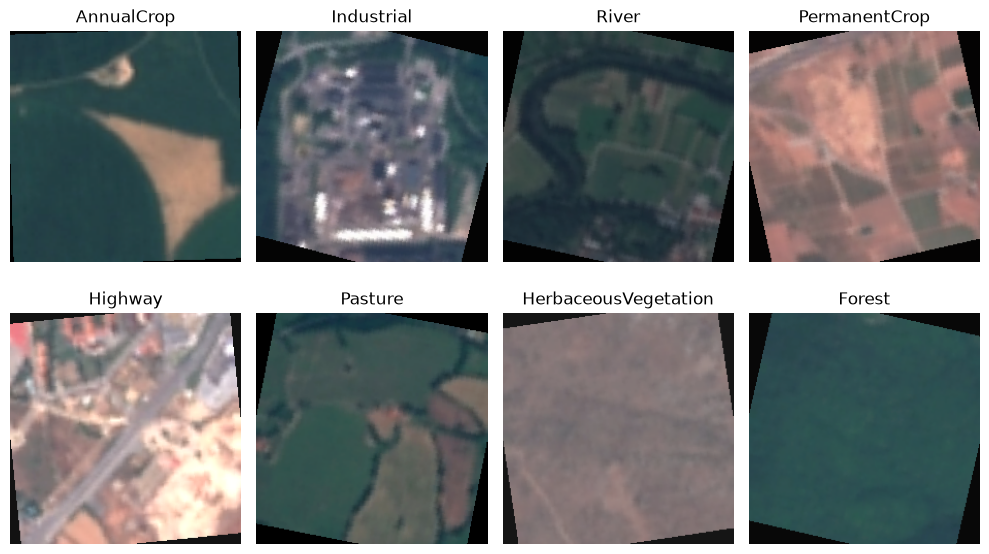

In [29]:
import matplotlib.pyplot as plt

mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)

images, labels = next(iter(train_loader))

fig, axes = plt.subplots(2,4, figsize=(10,6))

for i, ax in enumerate(axes.flatten()):
    img = images[i] * std + mean
    img = img.permute(1,2,0).numpy()

    ax.imshow(img.clip(0,1))
    ax.set_title(classes[labels[i]])
    ax.axis("off")

plt.tight_layout()
plt.show()